# EXPERIMENTAL PROTOCOL: CRP VALIDATION & REPLICATION (MARWAN 2002)

## A. SCIENTIFIC REPLICATION (TÁI TẠO KHOA HỌC)

### 1. Experiment 1: Noisy Periodic Data
**Purpose:** Kiểm chứng khả năng định vị độ trễ và đánh giá độ bền bỉ trước nhiễu của các chỉ số CRP.
*   **Setup:** $f(x) = \sin(x)$ và $g(x) = -\cos(x) + \xi$ ($SNR = 0.5$); $N = 500, \Delta x = 2\pi/100$; Nhúng: $m = 3, \tau = 25, \epsilon = 1.5$.
*   **Expected Visual Outputs (Kiến trúc biểu đồ tái tạo):**
    *   **Figure 1 (Time Series):** Đồ thị dọc 2 panel. Trục $x \in [0, 21]$, trục $y \in [-3, 3]$. 
        *   *Panel A:* Sóng $f(x)$ sạch, biên độ $\approx \pm1.414$.
        *   *Panel B:* Sóng $g(x)$ nhiễu dao động erratic mạnh trong dải $[-2.5, 2.5]$.
    *   **Figure 2 (CRP Map):** Ma trận vuông đen trắng hiển thị các dải chéo đứt gãy do nhiễu. Khoảng cách giữa các dải chính xác bằng chu kỳ $\lambda = 2\pi \approx 6.28$. Trục tọa độ $x, y$ chạy từ 0 đến 21.
    *   **Figure 3 (Lag Quantification):** Lưới đồ thị 2x2 quét lag $t \in [-10, 10]$ đơn vị thời gian.
        *   *Panel A (CC):* Dạng cosin, cực đại tại lag $\approx -1.57$ ($-\pi/2$) và $4.71$. Có vạch ý nghĩa 5% ($\approx \pm 0.1$).
        *   *Panel B (RR):* $RR_+$ tạo đỉnh tại $-1.57$ và $4.71$. $RR_-$ tạo đỉnh tại $1.57$ và $-4.71$. Max $\approx 0.5$.
        *   *Panel C (DET):* $DET_+$ nhọn sắc nét ($\approx 0.85$) tại các lag thuận; $DET_-$ tại các lag nghịch ($l_{min}=2$).
        *   *Panel D (L):* Dao động tuần hoàn nhẹ quanh dải $0.15 - 0.20$, tạo đỉnh khớp với mốc trễ liên kết.

### 2. Experiment 2: Lorenz–AR Nonlinear Coupling
**Purpose:** Khẳng định năng lực cốt lõi của CRP: Phát hiện liên kết phi tuyến dạng hàm chẵn ($x^2$) mà tương quan tuyến tính hoàn toàn bỏ sót.
*   **Setup:** Lorenz $x(t)$ ép quá trình $y_n = 0.86y_{n-1} + 0.5\xi_n + \kappa x_n^2$; $N = 8000$; Nhúng: $m = 5, \tau = 10, \epsilon = 2.0$.
*   **Expected Visual Outputs (Kiến trúc biểu đồ tái tạo):**
    *   **Figure 4 (Time Series & PSD):** Lưới 2x2.
        *   *Panel A & B:* Chuỗi $x(t) \in [40, 100]$ và $y(t) \in [40, 80]$ ở $\kappa=0.2$.
        *   *Panel C & D (PSD):* Bán log ($y \in 10^{-6}$ đến $10^0$). Đỉnh trội phổ $x$ tại tần số $0.34, 0.94$; phổ $y$ tại $1.30, 1.05$.
    *   **Figure 5 (CRP Map):** Cận cảnh hành vi quỹ đạo trong dải $t \in [41, 57]$. Hiển thị cấu trúc vân "ren" (lace-like) tinh xảo, thể hiện đồng bộ pha phi tuyến.
    *   **Figure 6 (CC vs. Mutual Information):** Lưới 2x2 đối chiếu năng lực.
        *   *Panel A & B (Linear CC):* Hoàn toàn phẳng lặng sát mốc 0 theo cả lag $[-0.5, 0.5]$ và lực $\kappa \in [0, 3]$. Bất lực trước liên kết phi tuyến.
        *   *Panel C & D (MI):* Tạo đỉnh nhọn tại lag $+0.05$ (đạt $0.43$) và các đỉnh phụ nhỏ ở $-0.29, 0.44$. Tăng trưởng đơn điệu theo $\kappa$ và bão hòa quanh $0.58$. Có dải xám biến động $2\sigma$.
    *   **Figure 7 (RR, DET, L Dynamics):** Lưới 3x2 đối chiếu biến thiên theo Lag (Cột trái, $\kappa=0.2$) và theo $\kappa$ (Cột phải, Lag=0). Có dải bóng mờ $2\sigma$.
        *   *Cột trái (vs. Lag):* $RR$ và $L$ cùng tạo đỉnh sắc nét tại mốc $+0.05$ cho cả mode Thuận/Nghịch. Riêng $RR_-$ có thêm đỉnh phụ ở $-0.3, +0.4$. Ngược lại, $DET$ phẳng lặng và nằm trọn trong dải $2\sigma$ (không mang ý nghĩa thống kê do chuỗi AR dao động quá nhanh).
        *   *Cột phải (vs. Coupling $\kappa$):* $RR$ tăng cực nhanh, bão hòa tại mức $0.27$ ngay khi $\kappa \ge 0.5$. $DET$ tăng chậm hơn, tiệm cận $1.0$ khi $\kappa \ge 2.0$. $L$ tăng rất chậm và đạt $\approx 0.28$ tại $\kappa=3.0$.



# CELL 1: Khai báo thư viện (Environment & Configurations)

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import correlate, correlation_lags, welch
from sklearn.feature_selection import mutual_info_regression

# =============================================================================
# LOCAL IMPORTS
# =============================================================================

sys.path.append(os.path.abspath(".."))

from core_ntsa.cross_rp import (
    embed_time_series,
    compute_cross_distance_matrix,
    compute_cross_recurrence_matrix,
    extract_lagged_diagonal_lengths,
    calculate_rr,
    calculate_det,
    calculate_l,
    compute_lagged_metrics,
    run_crp_analysis,
    analyze_lagged_interrelations,
)

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# =============================================================================
# PUBLICATION-QUALITY PLOT CONFIG
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.figsize": (10, 6),
    "axes.grid": False,
})

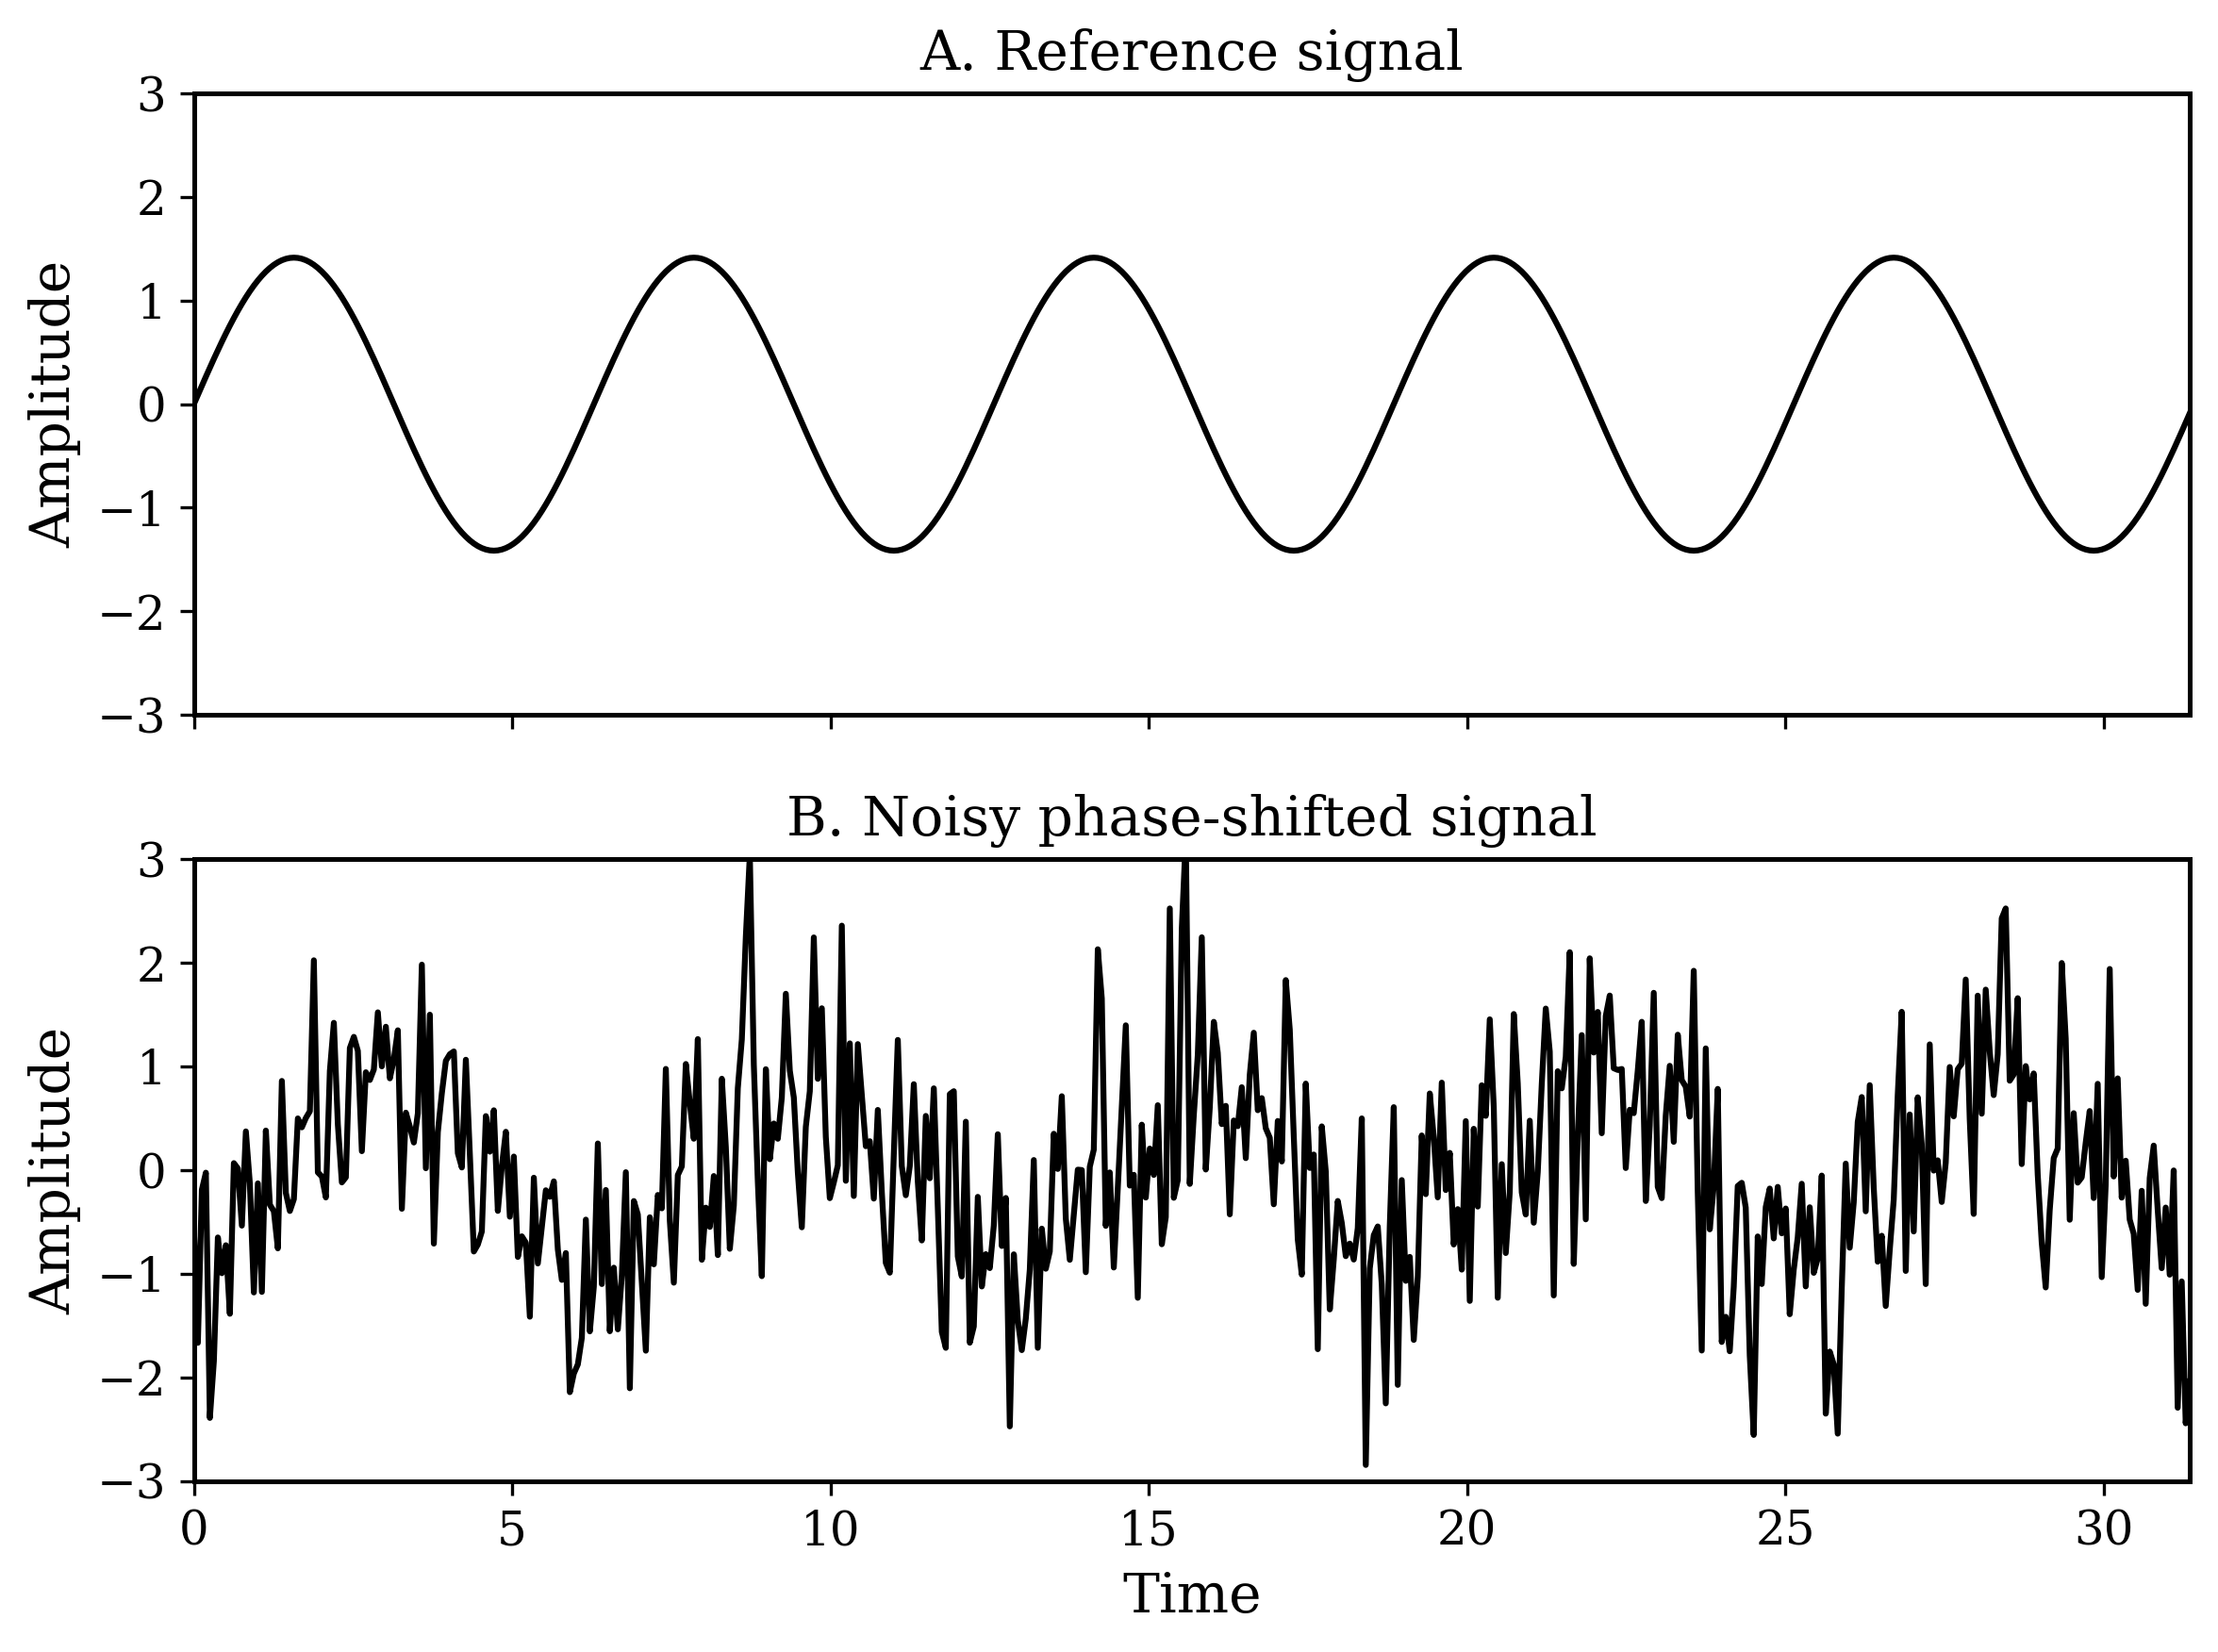

In [6]:
# =============================================================================
# CELL 5: GENERATE NOISY SINE & FIGURE 1
# =============================================================================

# Tái lập ngẫu nhiên
rng = np.random.default_rng(42)

# Trục thời gian
delta_x = 2 * np.pi / 100
x = np.arange(500) * delta_x

# Tạo tín hiệu
f = np.sin(x)
g = -np.cos(x) + rng.normal(0, 1.0, size=500)

# Z-score normalization
def zscore(signal):
    signal = np.asarray(signal)
    return (signal - np.mean(signal)) / np.std(signal)

f_z = zscore(f)
g_z = zscore(g)

# Figure 1
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(x, f_z, color="black")
axes[0].set_title("A. Reference signal")
axes[0].set_ylabel("Amplitude")
axes[0].set_ylim(-3, 3)
axes[0].set_xlim(0, x[-1])

axes[1].plot(x, g_z, color="black")
axes[1].set_title("B. Noisy phase-shifted signal")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Amplitude")
axes[1].set_ylim(-3, 3)
axes[1].set_xlim(0, x[-1])

plt.tight_layout()
plt.show()

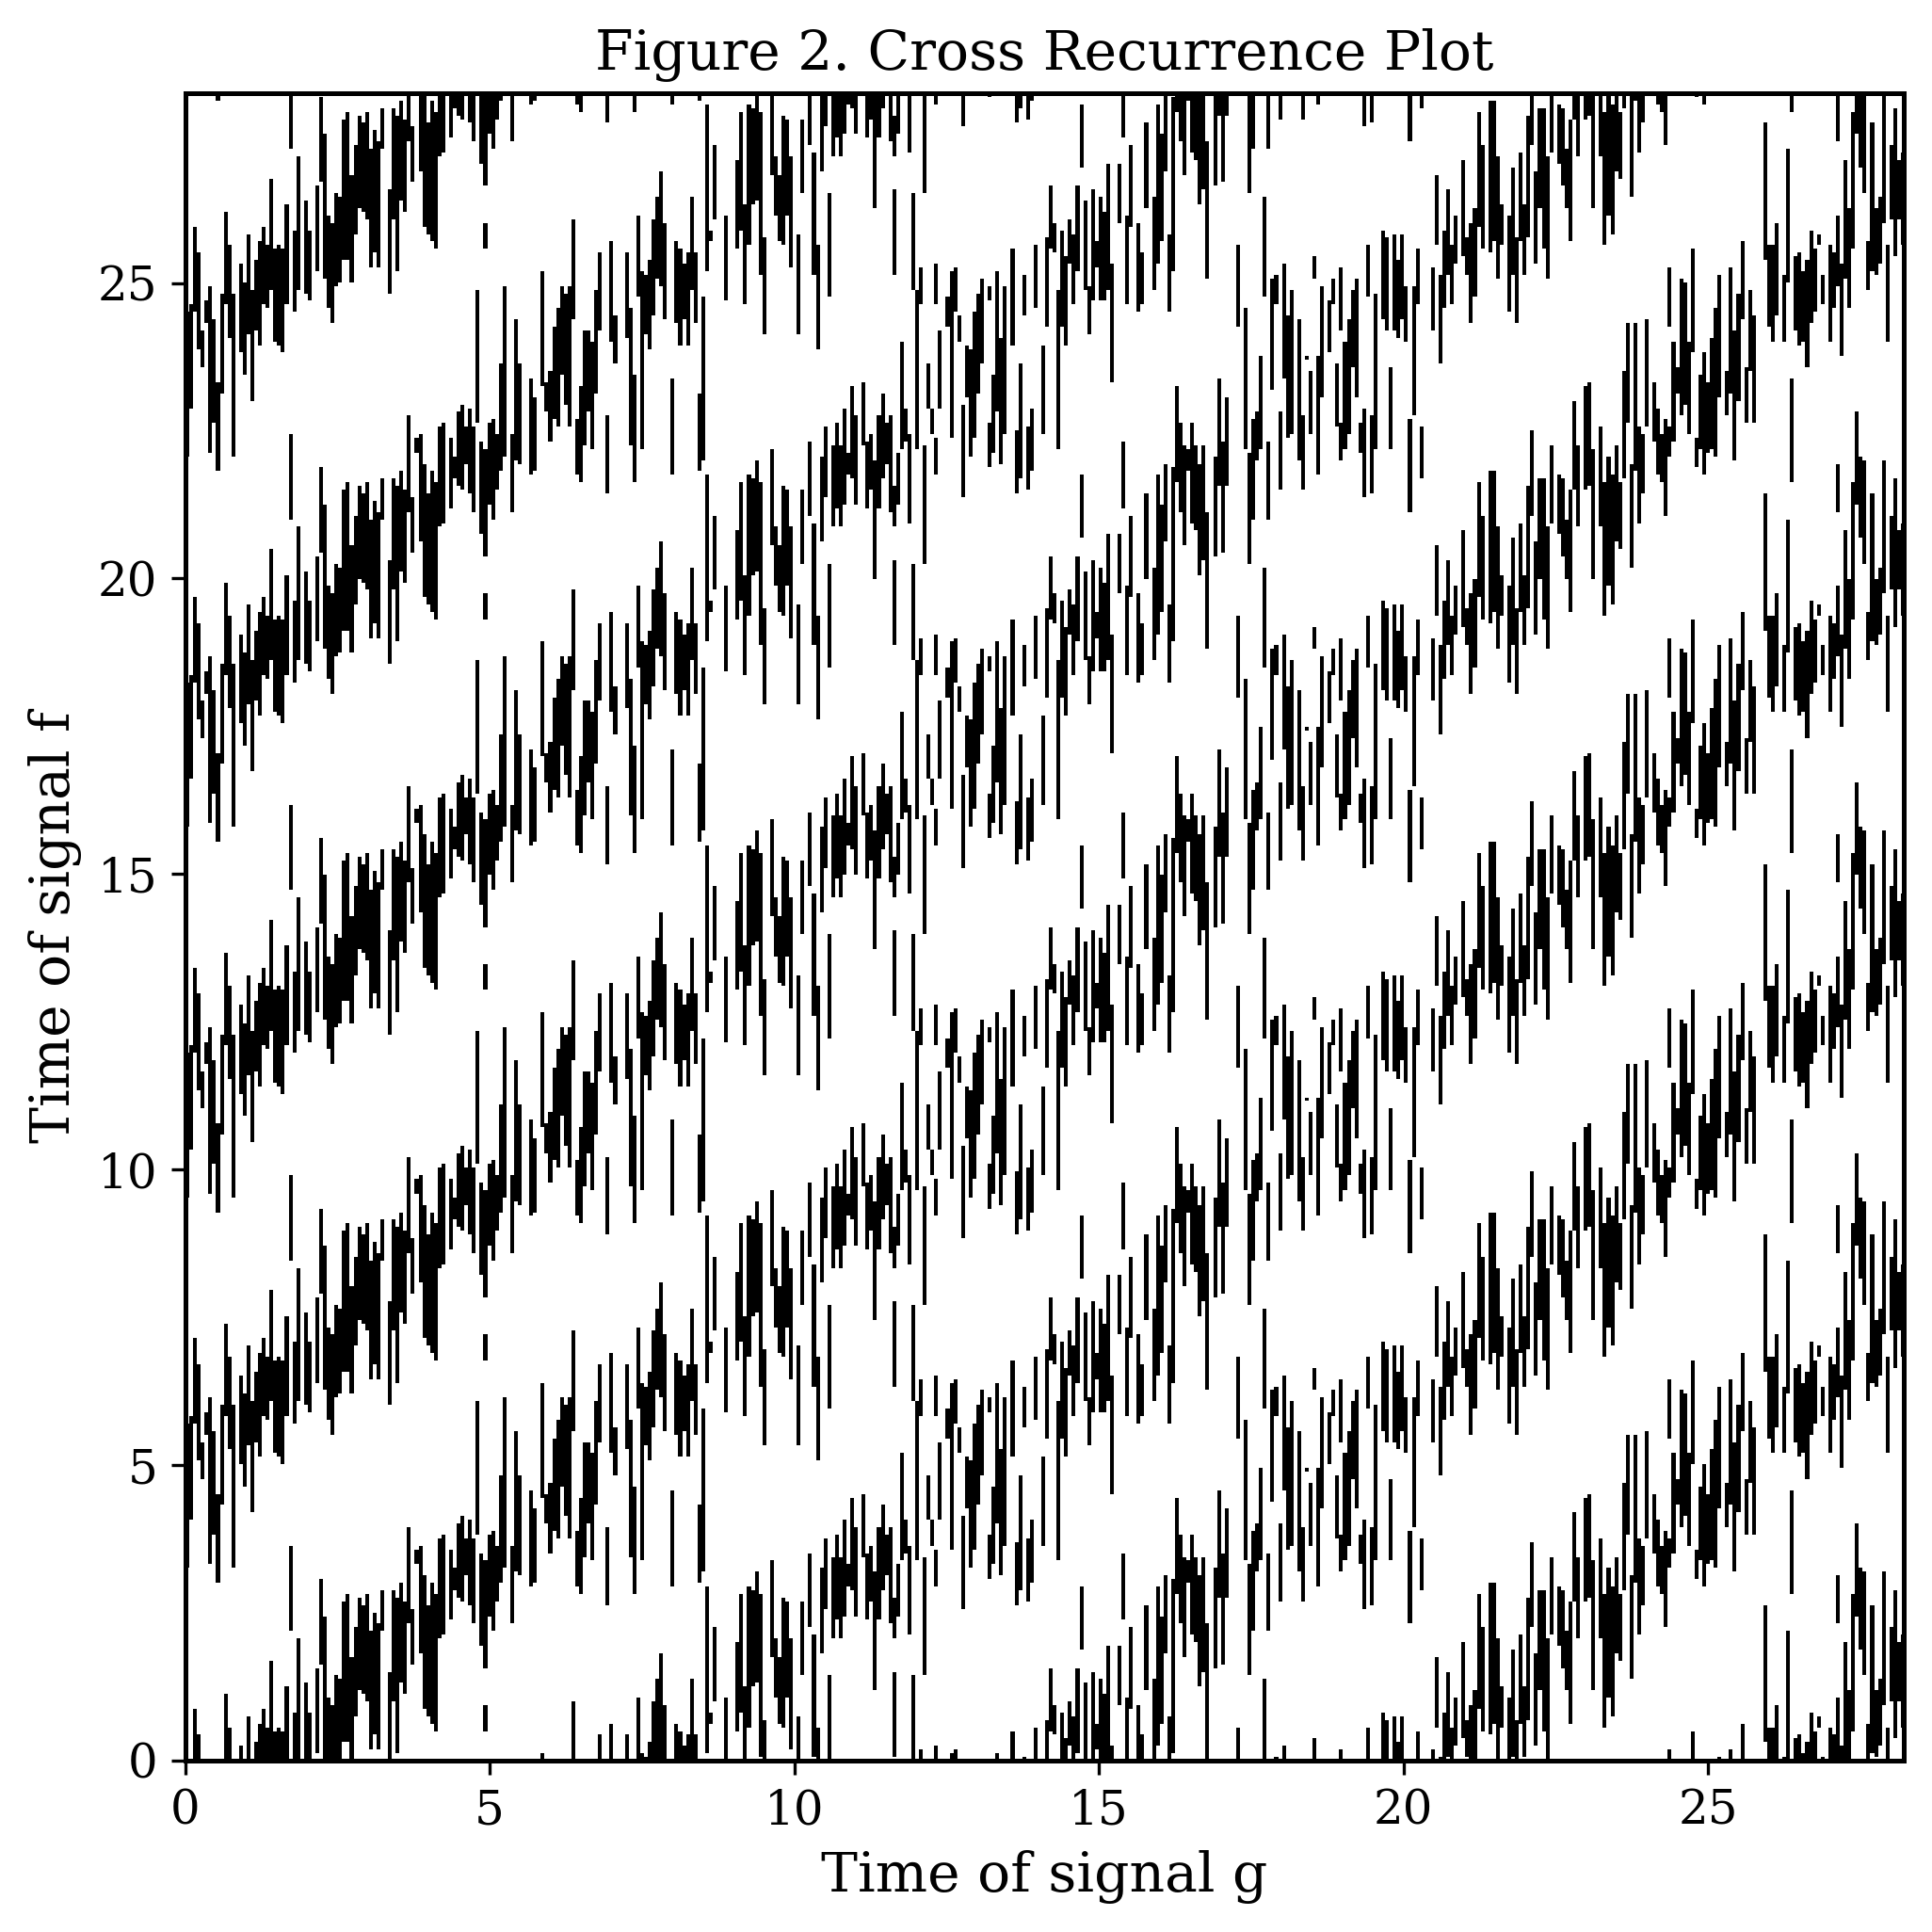

In [7]:
# =============================================================================
# CELL 6: CRP GEOMETRY & FIGURE 2
# =============================================================================

# Cấu hình CRP
m = 3
tau = 25
epsilon = 1.5

# Nhúng không gian pha
X = embed_time_series(f_z, m=m, tau=tau)
Y = embed_time_series(g_z, m=m, tau=tau)

# Ma trận khoảng cách và CRP
D = compute_cross_distance_matrix(X, Y)
CR = compute_cross_recurrence_matrix(D, epsilon=epsilon)

# Trục thời gian tương ứng với chỉ số bắt đầu của vector nhúng
x_emb = x[:X.shape[0]]

# Figure 2
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    CR,
    cmap="binary",
    origin="lower",
    interpolation="none",
    extent=[x_emb[0], x_emb[-1], x_emb[0], x_emb[-1]],
    aspect="auto"
)

ax.set_title("Figure 2. Cross Recurrence Plot")
ax.set_xlabel("Time of signal g")
ax.set_ylabel("Time of signal f")

plt.tight_layout()
plt.show()

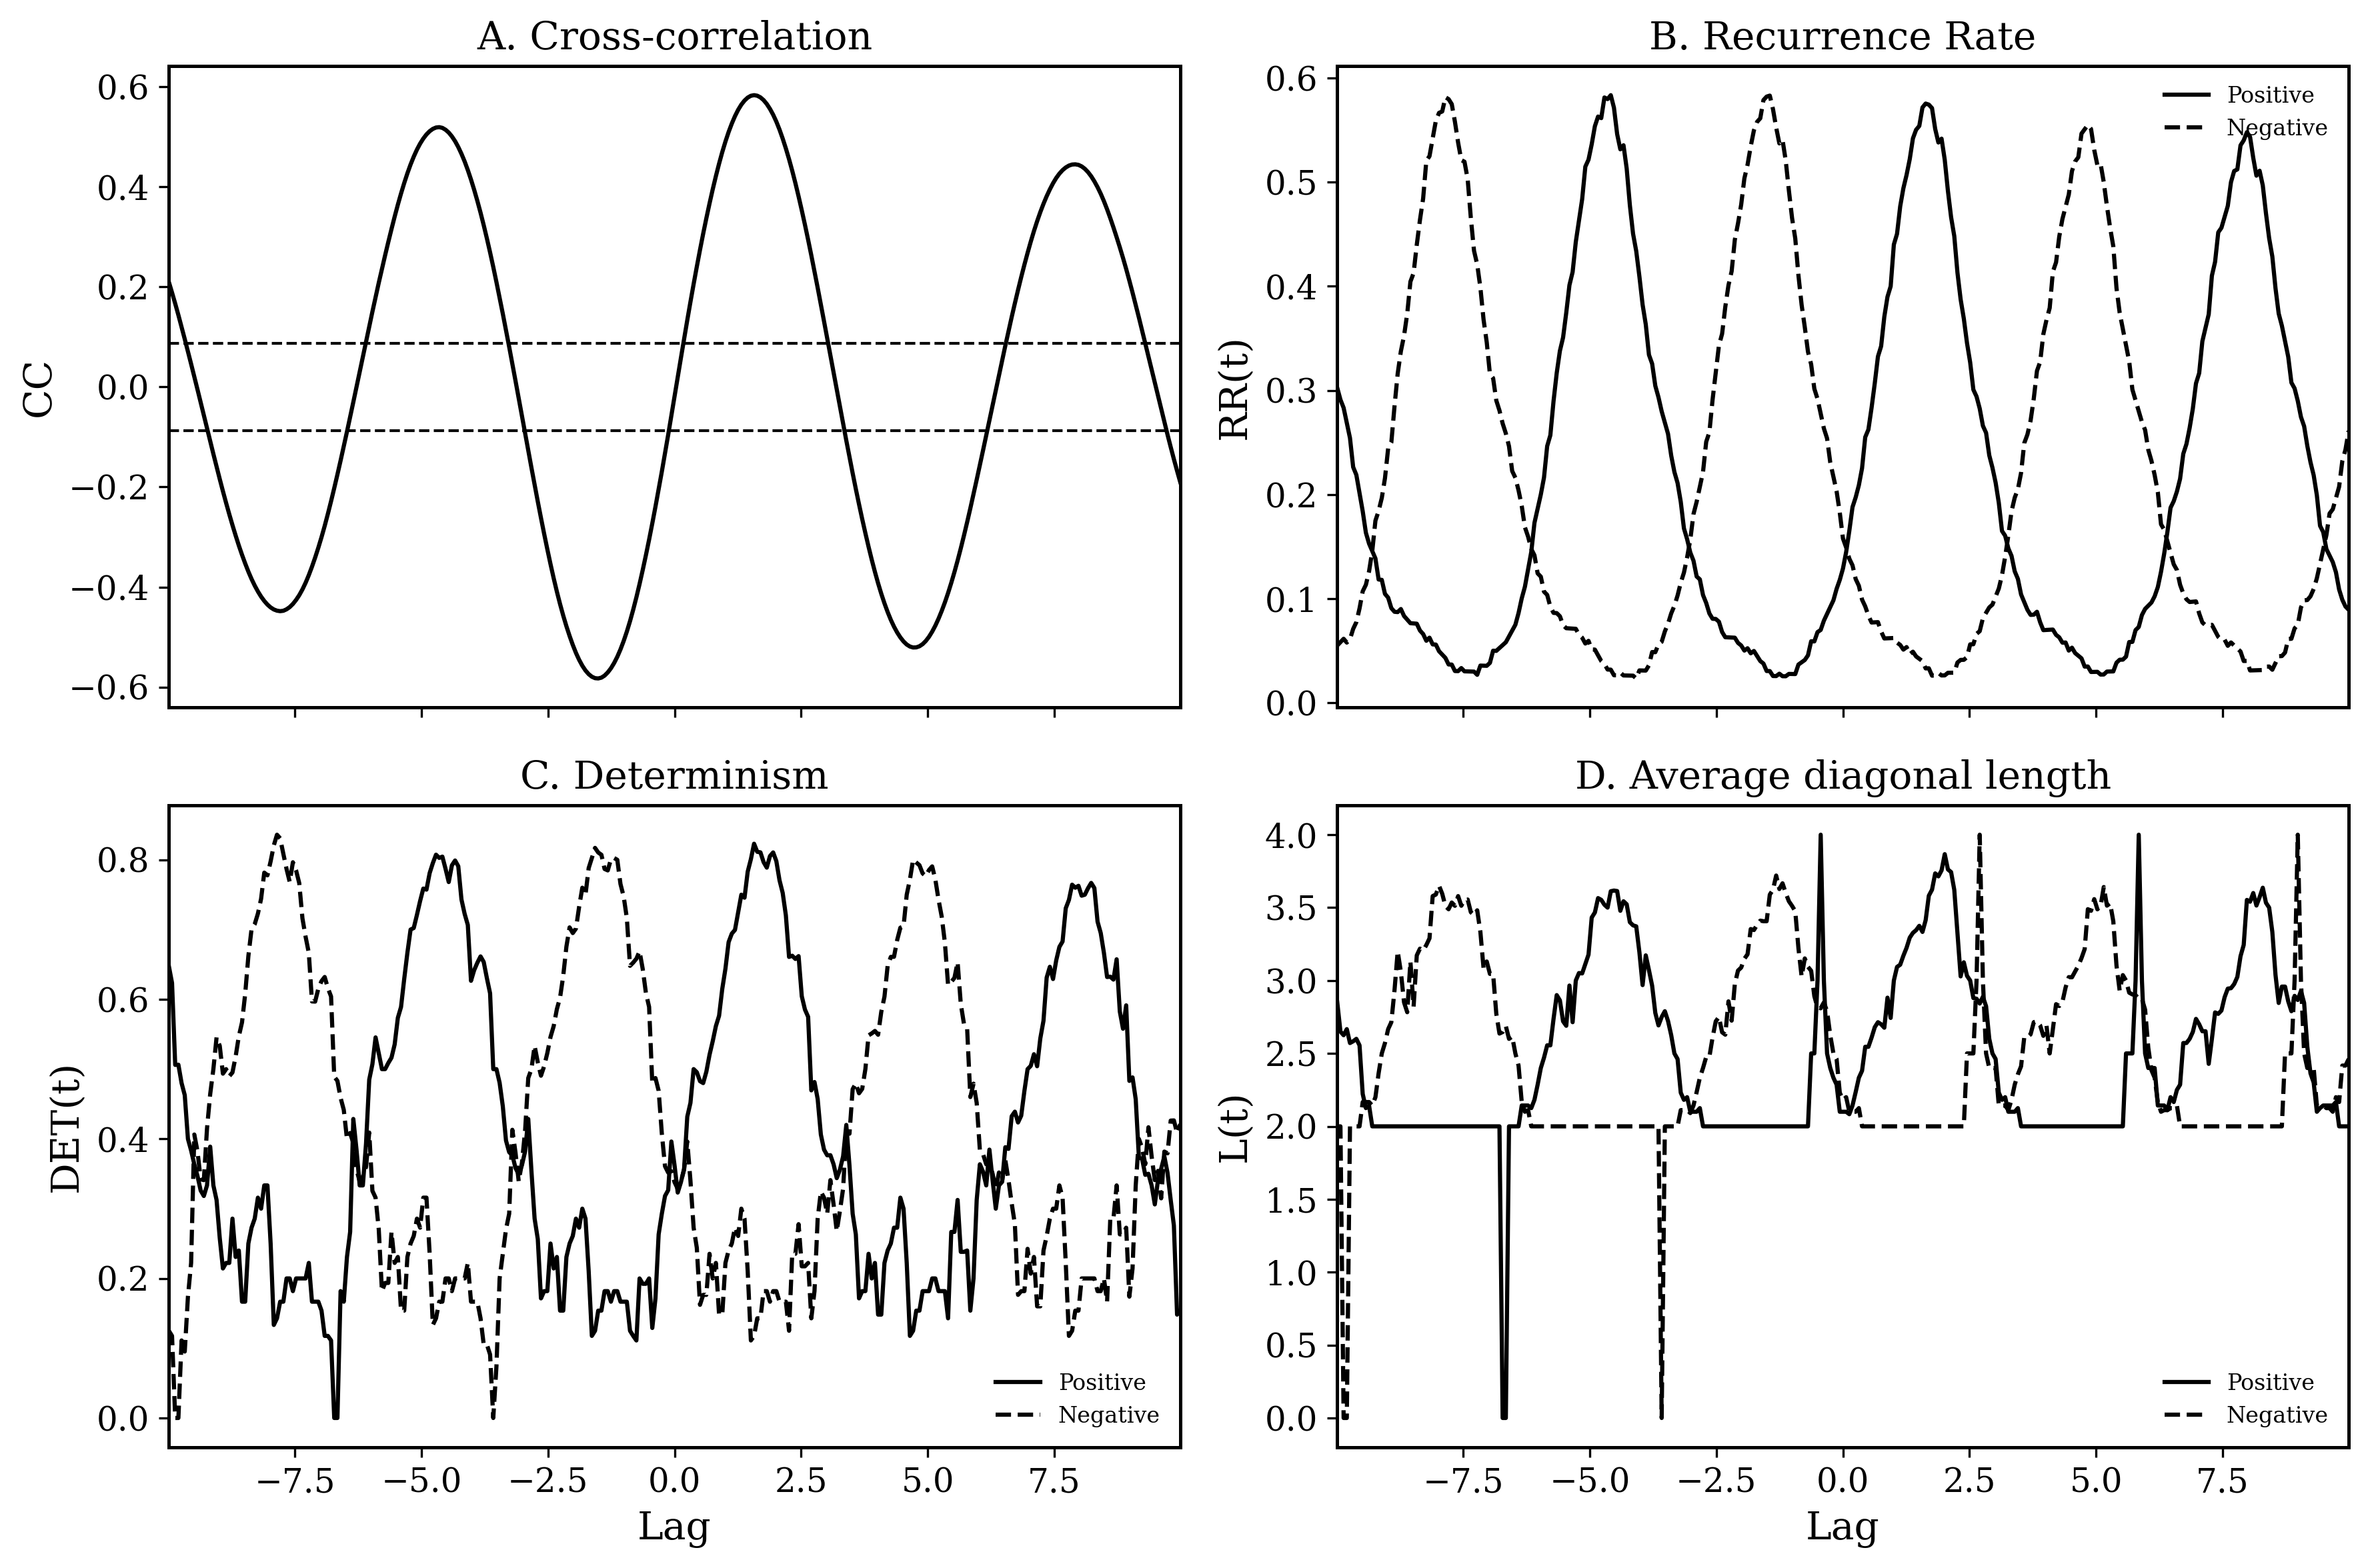

In [8]:
# =============================================================================
# CELL 7: CC + RR/DET/L & FIGURE 3
# =============================================================================

from scipy.signal import correlate, correlation_lags

# Cấu hình CRP
config = {
    "m": 3,
    "tau": 25,
    "epsilon": 1.5,
    "l_min": 2,
    "max_lag_T": 159
}

# -------------------------------------------------------------------------
# 1. Cross-correlation
# Convention:
# correlate(g, f) để peak lag khớp với convention CRP đã khóa trước đó
# -------------------------------------------------------------------------

cc_full = correlate(g_z, f_z, mode="full")
cc_lags_full = correlation_lags(len(g_z), len(f_z), mode="full")

# Chuẩn hóa về hệ số tương quan gần [-1, 1]
cc_full = cc_full / (np.linalg.norm(g_z) * np.linalg.norm(f_z))

# Chỉ lấy cửa sổ lag cần vẽ
lag_mask = (cc_lags_full >= -config["max_lag_T"]) & (cc_lags_full <= config["max_lag_T"])
cc_lags = cc_lags_full[lag_mask]
cc_values = cc_full[lag_mask]

# Đổi lag sang đơn vị thời gian
cc_time = cc_lags * delta_x

# Mốc ý nghĩa xấp xỉ 95%
conf95 = 1.96 / np.sqrt(len(f_z))

# -------------------------------------------------------------------------
# 2. CRP lag-dependent metrics
# -------------------------------------------------------------------------

results = analyze_lagged_interrelations(f_z, g_z, config=config)

lags = results["lags"]
lag_time = lags * delta_x

rr_pos = results["positive"]["RR"]
det_pos = results["positive"]["DET"]
l_pos = results["positive"]["L"]

rr_neg = results["negative"]["RR"]
det_neg = results["negative"]["DET"]
l_neg = results["negative"]["L"]

# -------------------------------------------------------------------------
# 3. Figure 3
# -------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

# Panel A: Cross-correlation
axes[0].plot(cc_time, cc_values, color="black", linestyle="-")
axes[0].axhline(conf95, color="black", linestyle="--", linewidth=1.0)
axes[0].axhline(-conf95, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("A. Cross-correlation")
axes[0].set_ylabel("CC")

# Panel B: RR
axes[1].plot(lag_time, rr_pos, color="black", linestyle="-", label="Positive")
axes[1].plot(lag_time, rr_neg, color="black", linestyle="--", label="Negative")
axes[1].set_title("B. Recurrence Rate")
axes[1].set_ylabel("RR(t)")
axes[1].legend(frameon=False)

# Panel C: DET
axes[2].plot(lag_time, det_pos, color="black", linestyle="-", label="Positive")
axes[2].plot(lag_time, det_neg, color="black", linestyle="--", label="Negative")
axes[2].set_title("C. Determinism")
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("DET(t)")
axes[2].legend(frameon=False)

# Panel D: L
axes[3].plot(lag_time, l_pos, color="black", linestyle="-", label="Positive")
axes[3].plot(lag_time, l_neg, color="black", linestyle="--", label="Negative")
axes[3].set_title("D. Average diagonal length")
axes[3].set_xlabel("Lag")
axes[3].set_ylabel("L(t)")
axes[3].legend(frameon=False)

for ax in axes:
    ax.set_xlim(lag_time[0], lag_time[-1])

plt.tight_layout()
plt.show()

### Cách đọc Figure 3

Bốn đồ thị cùng trả lời một câu hỏi: **hai tín hiệu liên hệ mạnh nhất tại độ trễ nào, và mối liên hệ đó có cấu trúc động lực học ra sao?**

- **Cross-Correlation (CC):** Cho biết hai waveform tương quan mạnh nhất tại những lag nào.
- **RR(t):** Cho biết tại lag đó, hai trajectory **thường xuyên đi qua các trạng thái gần nhau đến mức nào**.
- **DET(t):** Cho biết các recurrence points có **tổ chức thành những đoạn tiến hóa song hành** hay chỉ xuất hiện rời rạc.
- **L(t):** Cho biết mỗi đoạn tiến hóa tương đồng đó **duy trì trung bình bao lâu**.

Có thể ghi nhớ ngắn gọn:

> **CC = giống nhau ở lag nào**  
> **RR = gặp nhau bao nhiêu**  
> **DET = cùng tiến hóa có tổ chức đến đâu**  
> **L = cùng tiến hóa được bao lâu**

Trong kết quả này, các peak của `RR`, `DET` và `L` xuất hiện tuần hoàn theo lag và phù hợp với quan hệ pha của hai tín hiệu. Hai mode **Positive** và **Negative** xen kẽ nhau theo chu kỳ, phản ánh việc quan hệ thuận và nghịch chuyển đổi khi dịch pha.

Điểm quan trọng nhất là: **CRP không chỉ xác định lag của mối liên hệ như cross-correlation, mà còn mô tả cấu trúc và thời gian duy trì của sự tương đồng động lực học giữa hai hệ.**

### Nhận xét kết quả Experiment 1

Kết quả tái tạo cho thấy CRP hoạt động đúng với trực giác hình học của phương pháp.

- **Cross-correlation** phục hồi rõ cấu trúc tuần hoàn và các lag đặc trưng của hai tín hiệu.
- **RR(t)** tạo các đỉnh tuần hoàn rất rõ, cho thấy xác suất hai hệ đi qua các trạng thái tương đồng tăng mạnh tại những độ trễ phù hợp với quan hệ pha đã biết.
- **DET(t)** cũng đạt cực đại tại các lag tương ứng, chứng tỏ recurrence không chỉ xuất hiện rời rạc mà còn tổ chức thành các đoạn tiến hóa song hành có cấu trúc.
- **L(t)** phản ánh thời gian duy trì của các đoạn tiến hóa tương đồng; do nhiễu làm phân mảnh các đường chéo nên đại lượng này dao động mạnh hơn RR và DET.

Hai mode **Positive** và **Negative** dịch pha tương hỗ theo đúng tính đối xứng của tín hiệu sin–cos. Điều này cho thấy phép đảo dấu tín hiệu thứ hai thực sự cho phép CRP phân biệt hai dạng quan hệ thuận/nghịch.

Kết quả quan trọng nhất là:

\[
\boxed{\text{CRP không chỉ phát hiện rằng hai tín hiệu có liên hệ, mà còn chỉ ra liên hệ đó mạnh nhất tại lag nào và có cấu trúc động lực học ra sao.}}
\]

Trong thực nghiệm tuyến tính tuần hoàn này, CRP nhất quán với cross-correlation, nhưng đồng thời cung cấp thêm thông tin về **mật độ recurrence, mức độ tổ chức của diagonal và thời gian duy trì sự tiến hóa tương đồng**.

In [9]:
# =============================================================================
# CELL 8: LORENZ & FORCED AR GENERATORS
# =============================================================================

DT = 0.01
N_DATA = 8000
N_BURN = 2000


def zscore(signal):
    signal = np.asarray(signal, dtype=float)
    return (signal - np.mean(signal)) / np.std(signal)


def generate_lorenz(
    dt=DT,
    n_data=N_DATA,
    n_burn=N_BURN,
    initial_state=(1.0, 1.0, 1.0)
):
    """Generate Lorenz x(t) using solve_ivp with RK45."""

    sigma = 10.0
    rho = 28.0
    beta = 8.0 / 3.0

    def lorenz_rhs(t, state):
        x, y, z = state
        return [
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z
        ]

    n_total = n_burn + n_data
    t_eval = np.arange(n_total) * dt

    sol = solve_ivp(
        lorenz_rhs,
        (t_eval[0], t_eval[-1]),
        initial_state,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-9,
        atol=1e-12
    )

    x = sol.y[0, n_burn:]
    x = zscore(x)

    t = np.arange(n_data) * dt

    return t, x


def generate_forced_ar(x, kappa, rng, normalize=True):
    """Generate AR(1) process forced by kappa * x^2."""

    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    noise = rng.normal(0.0, 1.0, len(x))

    for n in range(1, len(x)):
        y[n] = (
            0.86 * y[n - 1]
            + 0.5 * noise[n]
            + kappa * x[n] ** 2
        )

    if normalize:
        y = zscore(y)

    return y


# Generate common Lorenz forcing
t_lorenz, x_lorenz = generate_lorenz()

# Example realization used for Figures 4 and 5
rng_example = np.random.default_rng(2002)
y_k02 = generate_forced_ar(
    x_lorenz,
    kappa=0.2,
    rng=rng_example,
    normalize=True
)

print("Lorenz length:", len(x_lorenz))
print("x mean/std:", np.mean(x_lorenz), np.std(x_lorenz))
print("y mean/std:", np.mean(y_k02), np.std(y_k02))

Lorenz length: 8000
x mean/std: -7.105427357601002e-18 1.0
y mean/std: -1.4566126083082054e-16 1.0


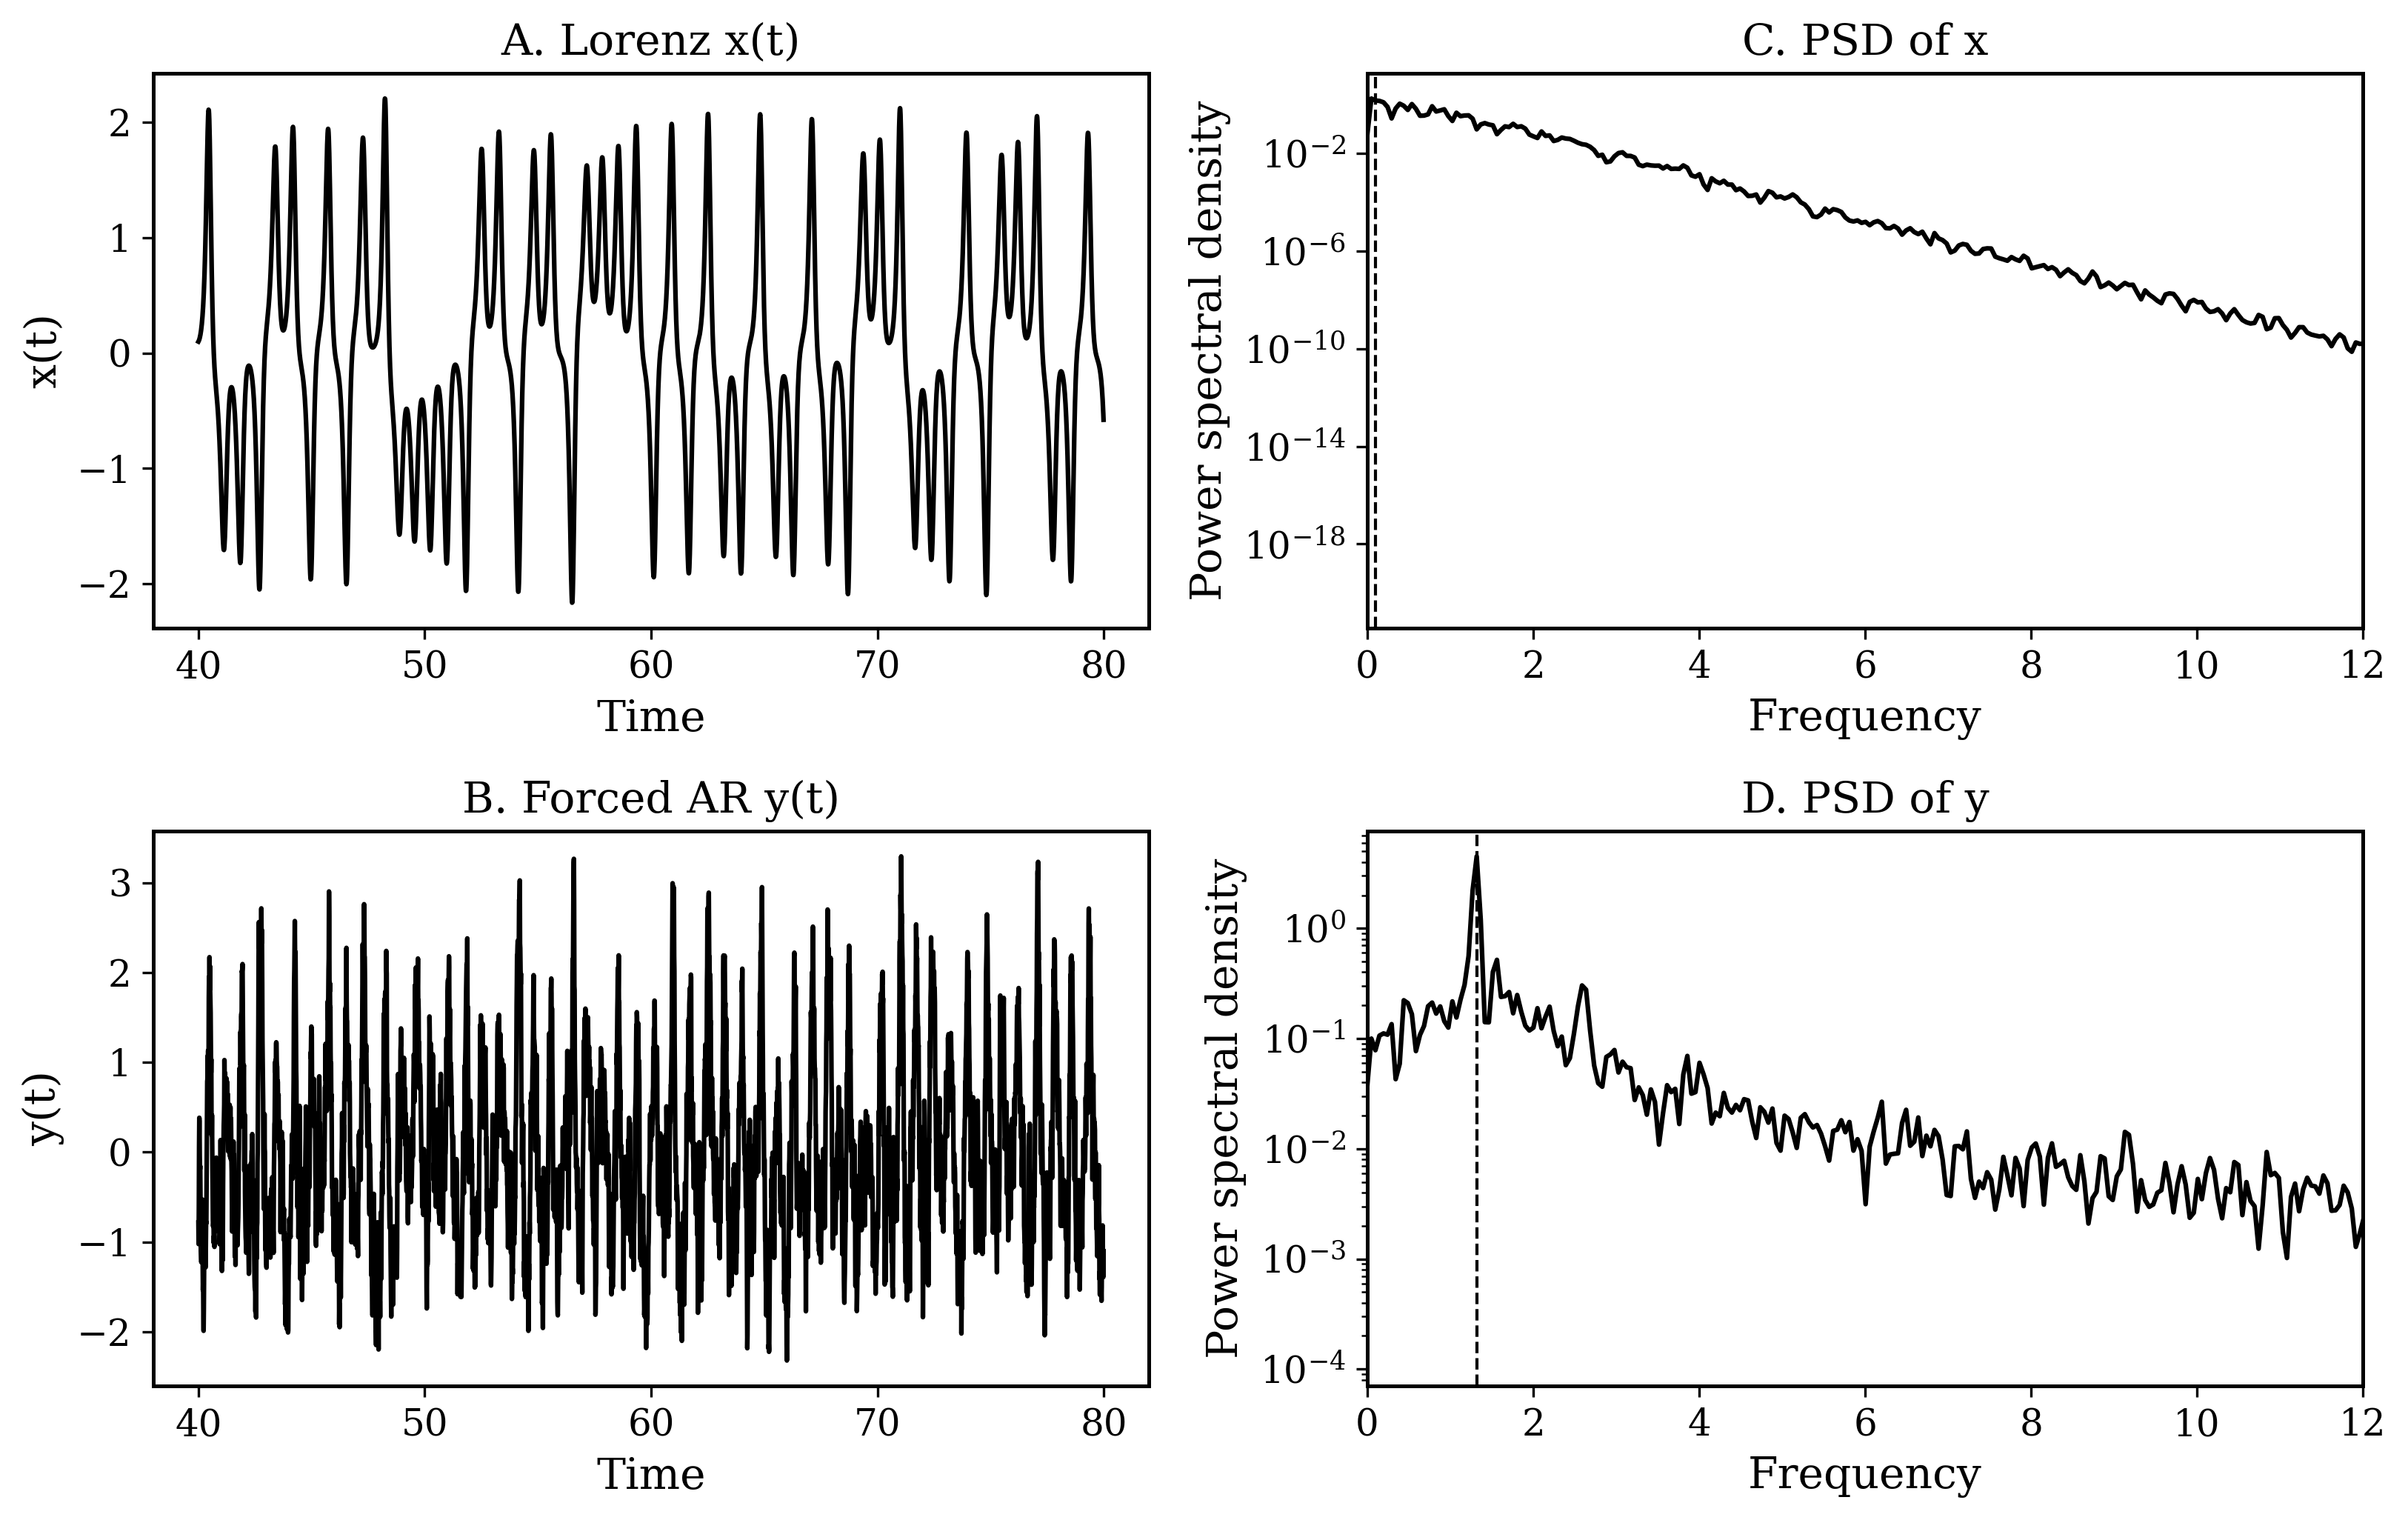

Dominant x frequency: 0.098
Dominant y frequency: 1.318


In [10]:
# =============================================================================
# CELL 9: TIME SERIES + PSD — FIGURE 4
# =============================================================================

fs = 1.0 / DT

# Welch PSD
freq_x, psd_x = welch(
    x_lorenz,
    fs=fs,
    nperseg=2048,
    detrend="constant"
)

freq_y, psd_y = welch(
    y_k02,
    fs=fs,
    nperseg=2048,
    detrend="constant"
)

# Dominant frequencies
mask_x = (freq_x > 0.05) & (freq_x < 3.0)
mask_y = (freq_y > 0.05) & (freq_y < 3.0)

peak_x = freq_x[mask_x][np.argmax(psd_x[mask_x])]
peak_y = freq_y[mask_y][np.argmax(psd_y[mask_y])]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# A: Lorenz x(t)
mask = (t_lorenz >= 40) & (t_lorenz <= 100)
axes[0, 0].plot(t_lorenz[mask], x_lorenz[mask], color="black")
axes[0, 0].set_title("A. Lorenz x(t)")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("x(t)")

# B: Forced AR y(t)
mask = (t_lorenz >= 40) & (t_lorenz <= 80)
axes[1, 0].plot(t_lorenz[mask], y_k02[mask], color="black")
axes[1, 0].set_title("B. Forced AR y(t)")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("y(t)")

# C: PSD of x
axes[0, 1].semilogy(freq_x, psd_x, color="black")
axes[0, 1].axvline(peak_x, linestyle="--", color="black", linewidth=1)
axes[0, 1].set_xlim(0, 12)
axes[0, 1].set_title("C. PSD of x")
axes[0, 1].set_xlabel("Frequency")
axes[0, 1].set_ylabel("Power spectral density")

# D: PSD of y
axes[1, 1].semilogy(freq_y, psd_y, color="black")
axes[1, 1].axvline(peak_y, linestyle="--", color="black", linewidth=1)
axes[1, 1].set_xlim(0, 12)
axes[1, 1].set_title("D. PSD of y")
axes[1, 1].set_xlabel("Frequency")
axes[1, 1].set_ylabel("Power spectral density")

plt.tight_layout()
plt.show()

print(f"Dominant x frequency: {peak_x:.3f}")
print(f"Dominant y frequency: {peak_y:.3f}")

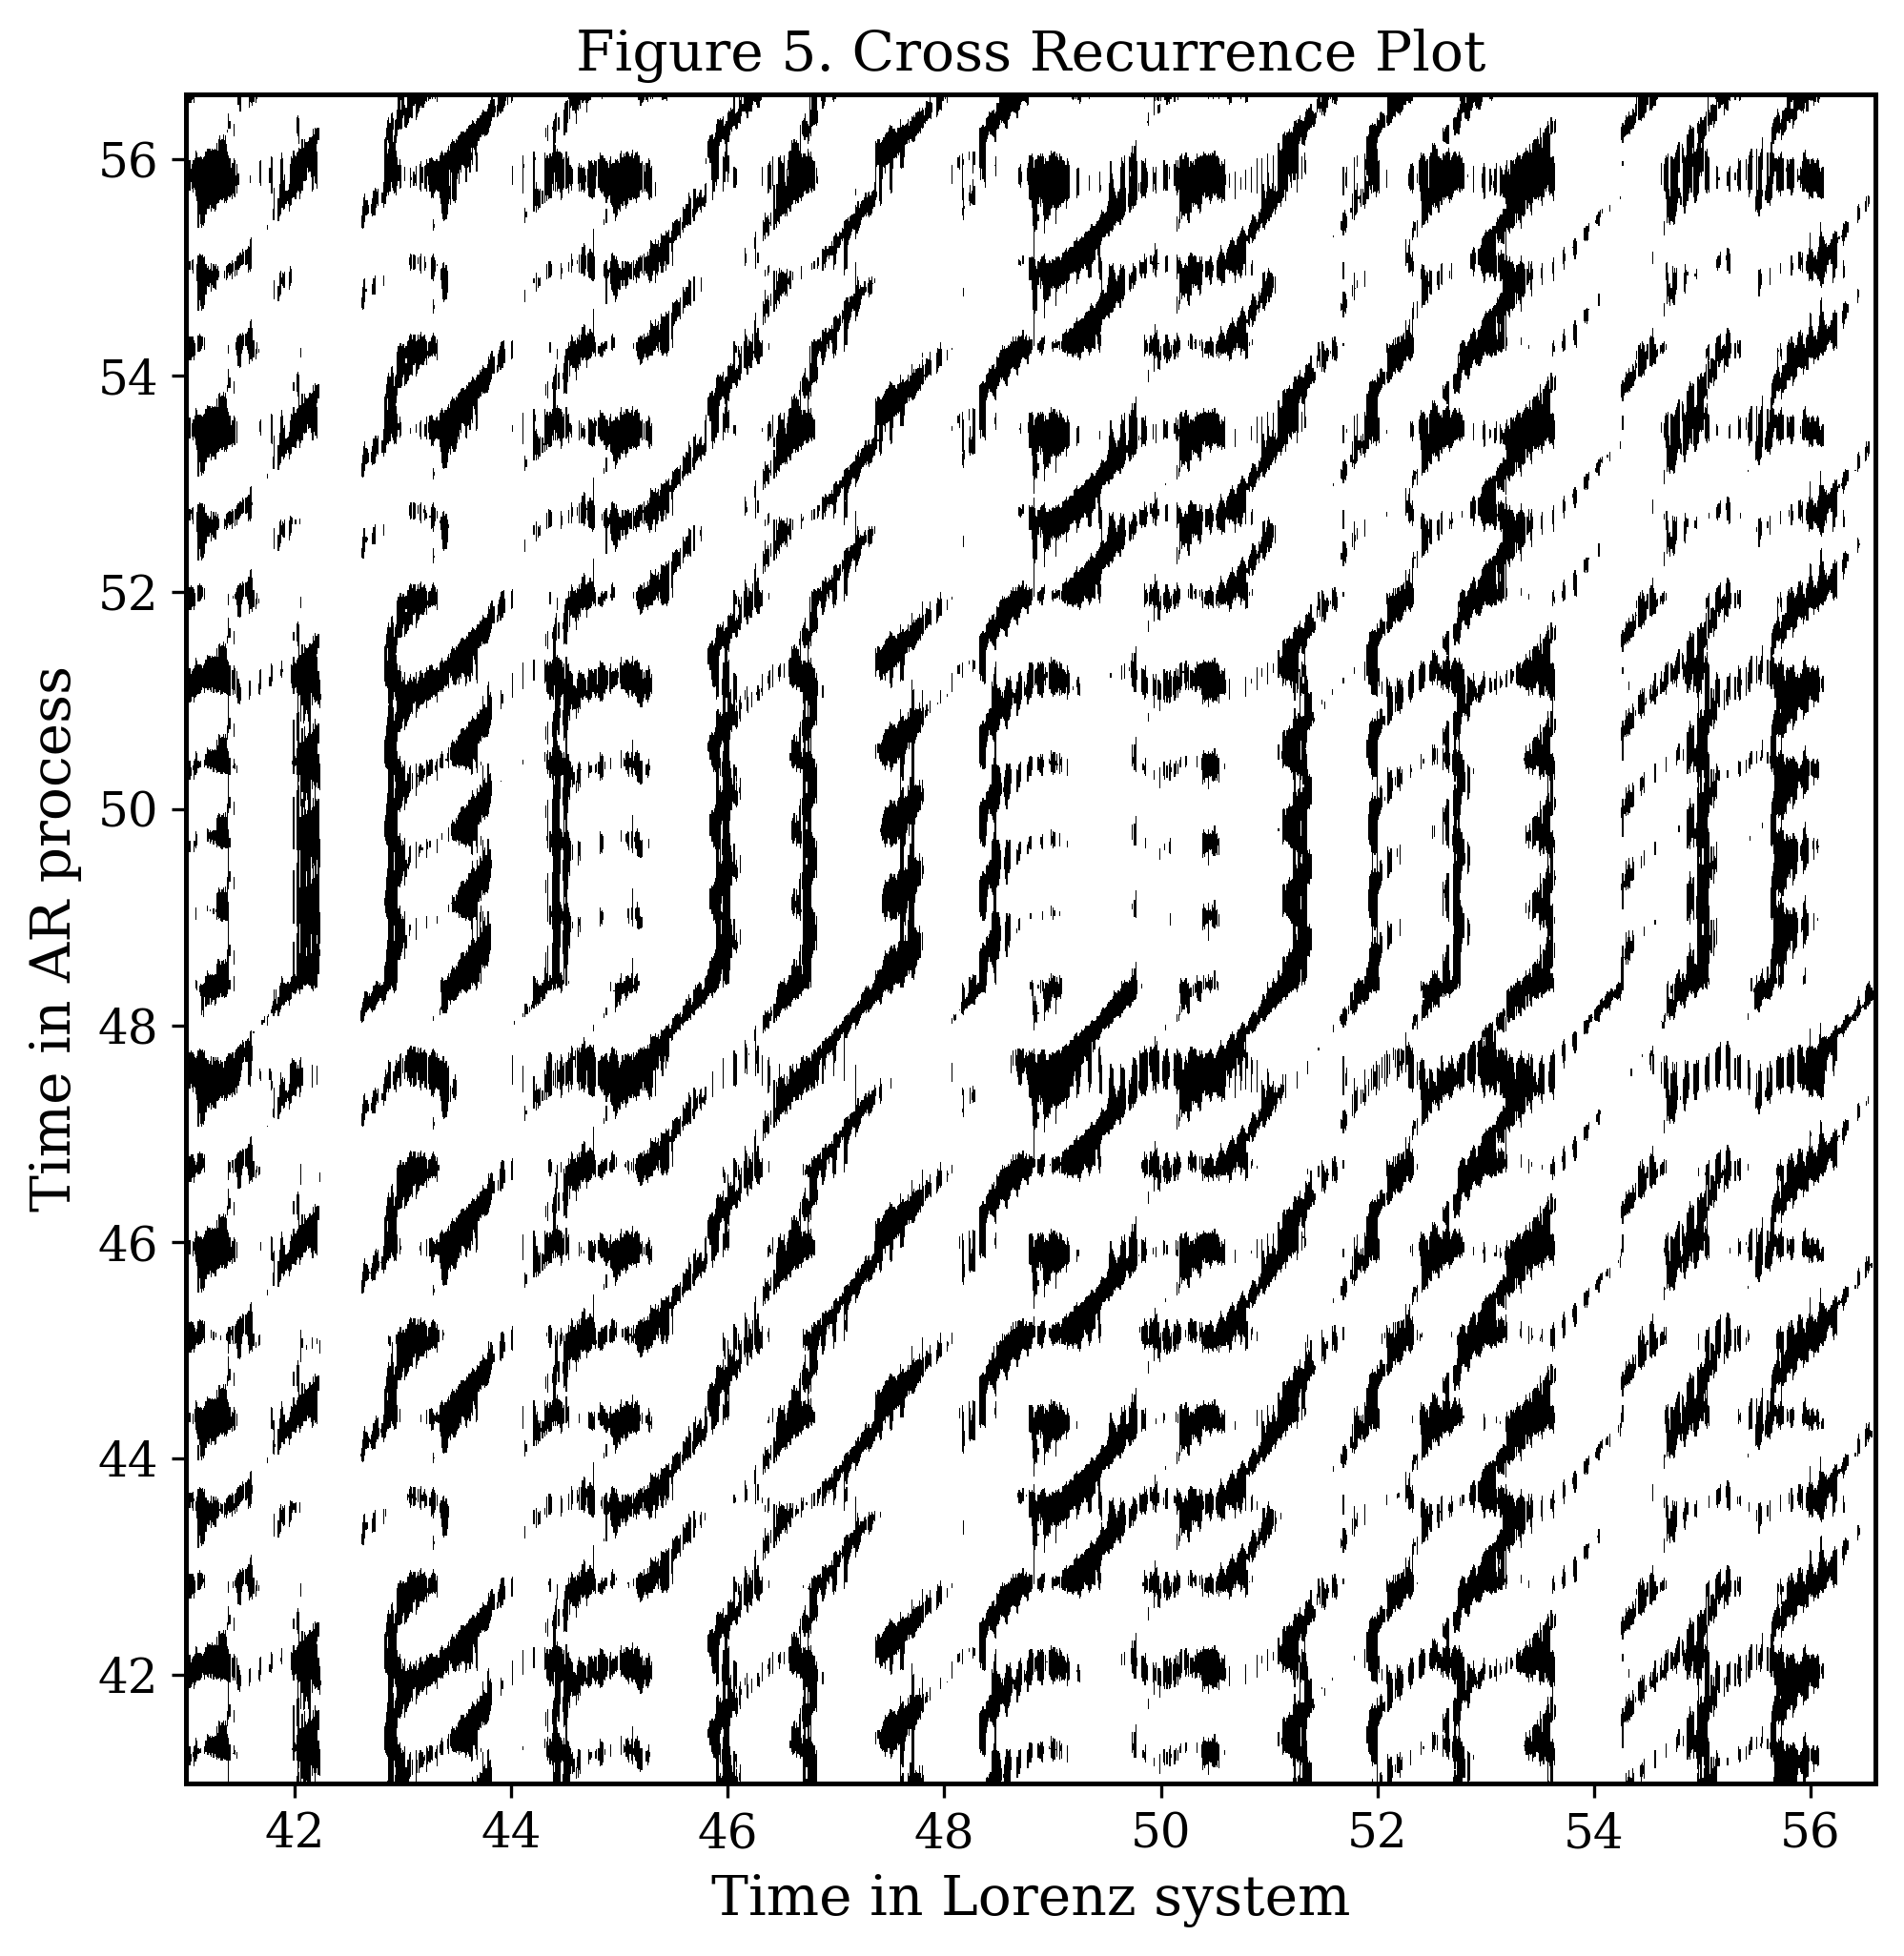

In [11]:
# =============================================================================
# CELL 10: LOCAL CROSS RECURRENCE PLOT — FIGURE 5
# =============================================================================

m = 5
tau = 10
epsilon = 2.0

# Window shown in the paper
local_mask = (t_lorenz >= 41) & (t_lorenz <= 57)

x_local = x_lorenz[local_mask]
y_local = y_k02[local_mask]
t_local = t_lorenz[local_mask]

# Phase-space reconstruction
X_local = embed_time_series(x_local, m=m, tau=tau)
Y_local = embed_time_series(y_local, m=m, tau=tau)

# Full CRP is feasible for this short window
D_local = compute_cross_distance_matrix(X_local, Y_local)
CR_local = compute_cross_recurrence_matrix(D_local, epsilon=epsilon)

t_emb = t_local[:X_local.shape[0]]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    CR_local,
    cmap="binary",
    origin="lower",
    interpolation="none",
    extent=[t_emb[0], t_emb[-1], t_emb[0], t_emb[-1]],
    aspect="equal"
)

ax.set_title("Figure 5. Cross Recurrence Plot")
ax.set_xlabel("Time in Lorenz system")
ax.set_ylabel("Time in AR process")

plt.tight_layout()
plt.show()